# Лабораторная работа № 8
## Нечёткие системы принятия решений на основе датасета Student Performance

## Загрузка и описание данных

Датасет **Students Performance in Exams** содержит информацию об успеваемости учеников:
- **gender** – пол (female / male)
- **race/ethnicity** – расовая/этническая группа (group A–E)
- **parental level of education** – уровень образования родителей
- **lunch** – тип обеда (standard / free-reduced)
- **test preparation course** – пройден ли подготовительный курс (completed / none)
- **math score** – оценка по математике (0–100) – **целевая переменная**
- **reading score** – оценка по чтению (0–100)
- **writing score** – оценка по письму (0–100)

**Задача:** классификация – определить, сдаст ли ученик математику (math score ≥ 60 → pass/fail).

In [18]:
import pandas as pd

df = pd.read_csv("../../data/students_performance.csv")
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


#### Кодирование категориальных признаков и создание целевой переменной

Бинарные признаки кодируем вручную, для многозначных используем One-Hot Encoding.  
Целевая переменная: `math_pass = 1`, если оценка по математике ≥ 60, иначе `0`.

In [20]:
# Бинарное кодирование
df["lunch"] = df["lunch"].map({"standard": 1, "free/reduced": 0})
df["test preparation course"] = df["test preparation course"].map({"completed": 1, "none": 0})
df["gender"] = df["gender"].map({"female": 1, "male": 0})

# One-Hot Encoding для многозначных признаков
df = pd.get_dummies(
    df,
    columns=["race/ethnicity", "parental level of education"],
    drop_first=True,
)

# Целевая переменная
df["math pass"] = (df["math score"] >= 60).astype(int)

df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   gender                                         1000 non-null   int64
 1   lunch                                          1000 non-null   int64
 2   test preparation course                        1000 non-null   int64
 3   math score                                     1000 non-null   int64
 4   reading score                                  1000 non-null   int64
 5   writing score                                  1000 non-null   int64
 6   race/ethnicity_group B                         1000 non-null   bool 
 7   race/ethnicity_group C                         1000 non-null   bool 
 8   race/ethnicity_group D                         1000 non-null   bool 
 9   race/ethnicity_group E                         1000 non-null   bool 
 10  p

,gender,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,math pass
0,1,1,0,72,72,74,True,False,False,False,True,False,False,False,False,1
1,1,1,1,69,90,88,False,True,False,False,False,False,False,True,False,1
2,1,1,0,90,95,93,True,False,False,False,False,False,True,False,False,1
3,0,0,0,47,57,44,False,False,False,False,False,False,False,False,False,0
4,0,1,0,76,78,75,False,True,False,False,False,False,False,True,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,1,1,88,99,95,False,False,False,True,False,False,True,False,False,1
996,0,0,0,62,55,55,False,True,False,False,False,True,False,False,False,1
997,1,0,1,59,71,65,False,True,False,False,False,True,False,False,False,0
998,1,1,1,68,78,77,False,False,True,False,False,False,False,True,False,1


#### Матрица корреляции признаков

Матрица корреляции используется для выбора наиболее важных признаков и обнаружения мультиколлинеарности.

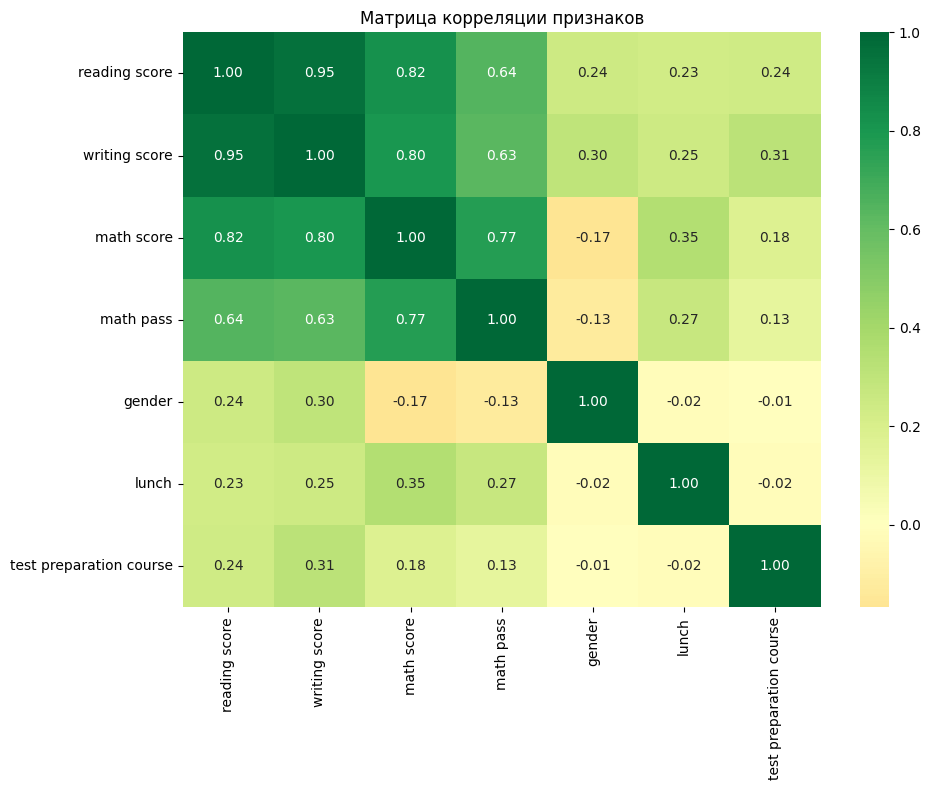

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Берём только числовые столбцы для наглядности
num_cols = ["reading score", "writing score", "math score", "math pass",
            "gender", "lunch", "test preparation course"]
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Матрица корреляции признаков")
plt.tight_layout()
plt.show()

**Выводы по матрице корреляции:**
- Наибольшая корреляция с `math pass` у **reading score** (~0.80) и **writing score** (~0.79) – это главные предикторы.
- `reading score` и `writing score` сильно коррелируют между собой (~0.95) – мультиколлинеарность, но оба важны для нечёткой системы.
- `test preparation course` и `lunch` дают умеренную корреляцию (~0.2–0.3) – вспомогательные признаки.

Для нечёткой системы выбираем три наиболее интерпретируемых признака: **reading score**, **writing score**, **test preparation course**.

#### Формирование обучающей и тестовой выборок

In [22]:
from sklearn.model_selection import train_test_split

seed = 42

X = df.drop(["math score", "math pass"], axis=1)
y = df["math pass"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка:  {X_test.shape[0]} строк")
print(f"Доля класса Pass в тесте: {y_test.mean():.2f}")

Обучающая выборка: 800 строк
Тестовая выборка:  200 строк
Доля класса Pass в тесте: 0.65


## Классическая модель машинного обучения – Дерево решений

Дерево решений выбрано как интерпретируемая модель: его правила можно напрямую использовать для построения нечёткой системы.

Точность на обучении: 0.88
Точность на тесте:   0.90
              precision    recall  f1-score   support

    Fail (0)       0.89      0.80      0.84        70
    Pass (1)       0.90      0.95      0.92       130

    accuracy                           0.90       200
   macro avg       0.89      0.87      0.88       200
weighted avg       0.89      0.90      0.89       200



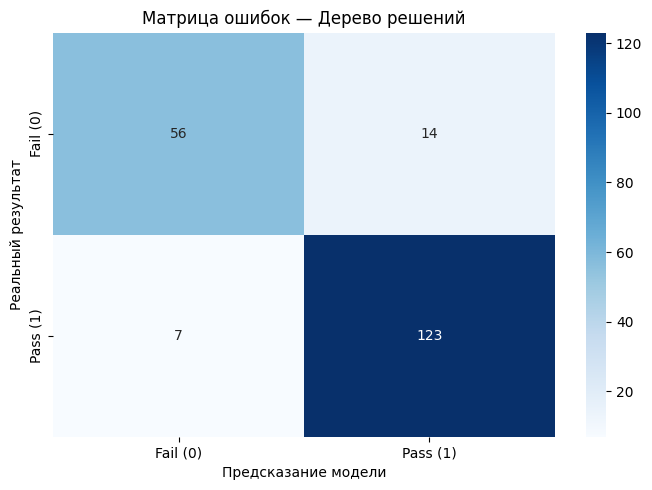

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=seed)
tree_model.fit(X_train, y_train)

train_score = tree_model.score(X_train, y_train)
test_score  = tree_model.score(X_test,  y_test)

print(f"Точность на обучении: {train_score:.2f}")
print(f"Точность на тесте:   {test_score:.2f}")

text_labels = ["Fail (0)", "Pass (1)"]
y_pred = tree_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=text_labels))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=text_labels, yticklabels=text_labels)
plt.xlabel("Предсказание модели")
plt.ylabel("Реальный результат")
plt.title("Матрица ошибок – Дерево решений")
plt.tight_layout()
plt.show()

#### Визуализация структуры дерева

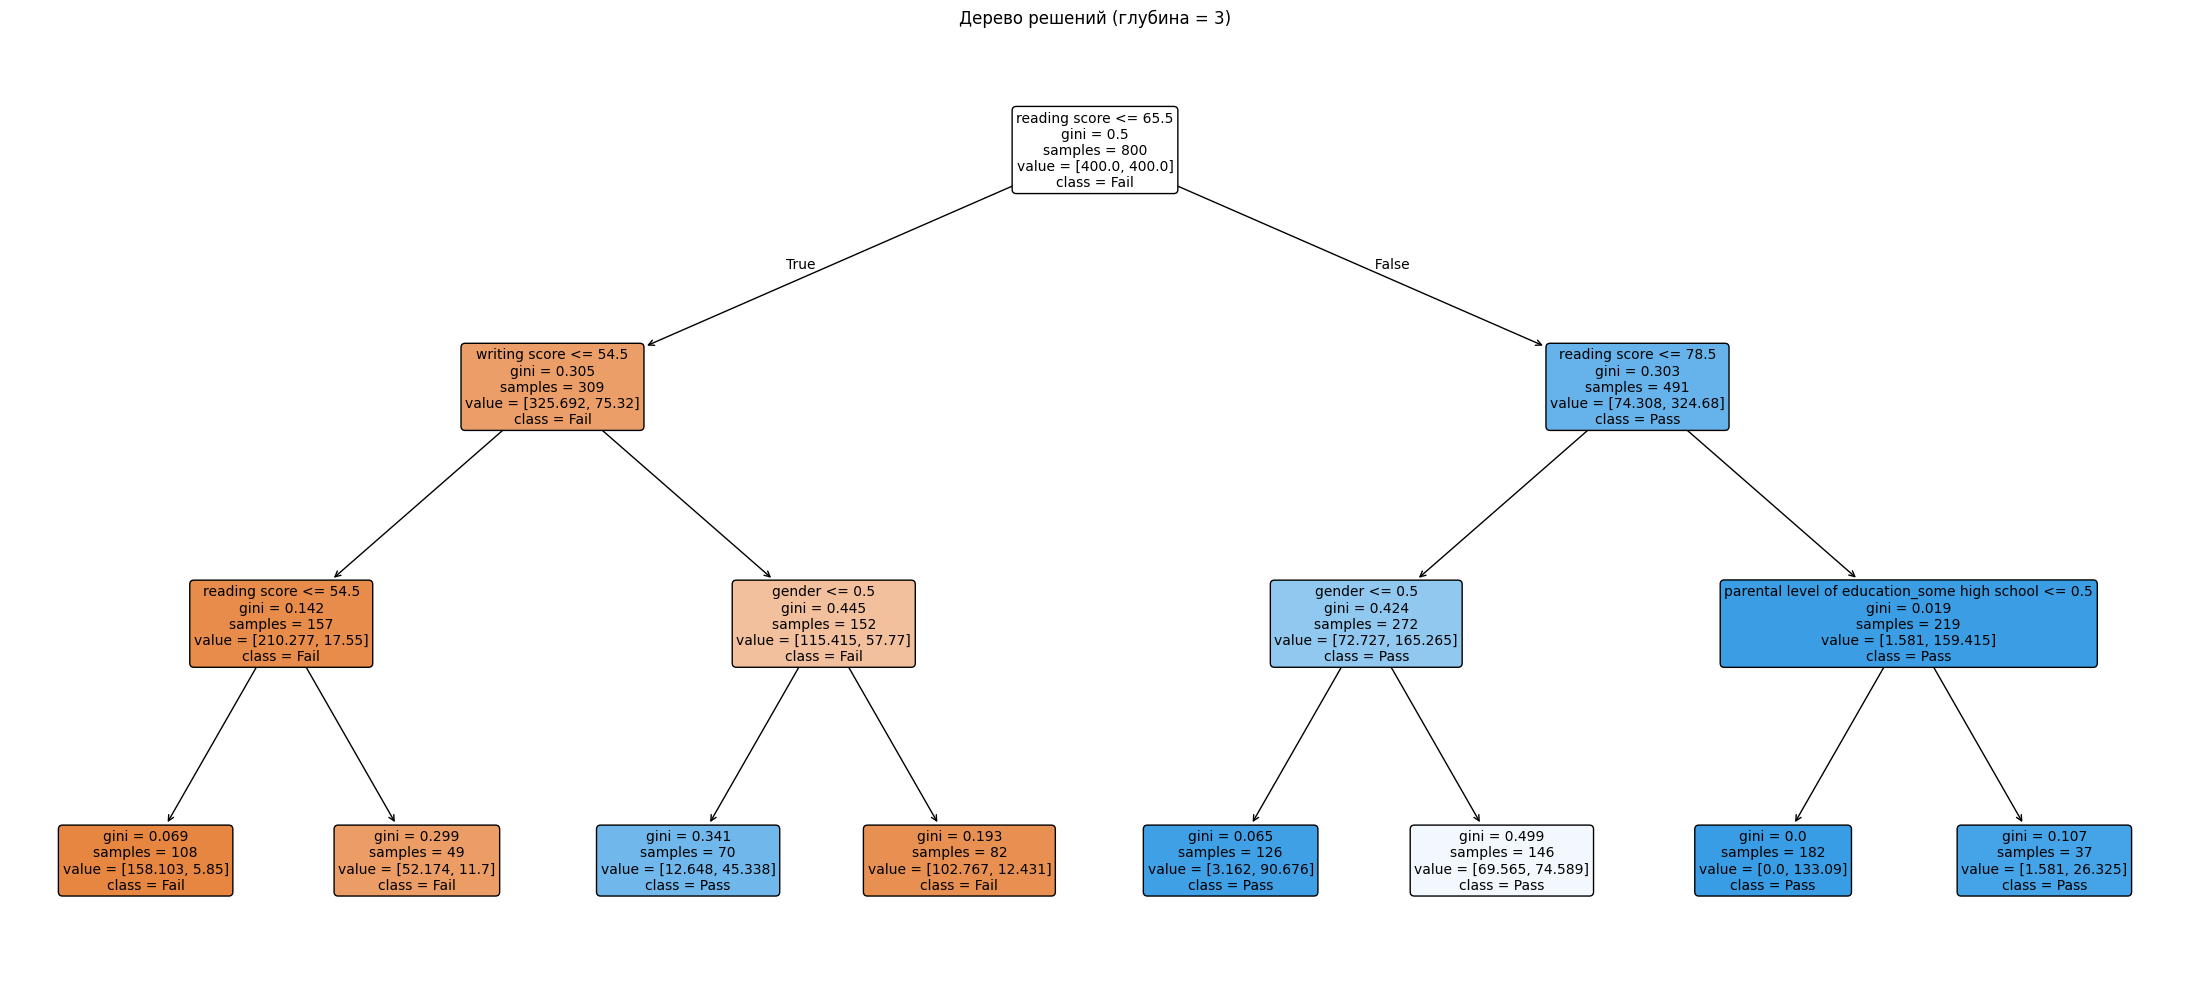

In [24]:
plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=list(X.columns),
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Дерево решений (глубина = 3)")
plt.tight_layout()
plt.show()

#### Извлечение нечётких правил из дерева решений

- Глубина дерева 3 даёт небольшое количество легко интерпретируемых правил.
- Для каждого признака вычисляются 33-й и 66-й перцентили как границы термов.
- Каждая ветвь дерева формирует одно правило.

In [25]:
import numpy as np

# Вычисляем границы термов для каждого признака
term_boundaries = {}
for col in X_train.columns:
    values = X_train[col]
    sample = values.tolist()[0]
    if isinstance(sample, bool) or set(values.unique()).issubset({0, 1, True, False}):
        term_boundaries[col] = (0, 1)
    else:
        term_boundaries[col] = (values.quantile(0.33), values.quantile(0.66))


def value_to_term(col: str, value: float, direction: str) -> str:
    """Преобразует числовой порог в название терма с учётом направления."""
    low, high = term_boundaries[col]
    if direction == "<=":
        if value <= low:
            return "низкий"
        elif value <= high:
            return "средний"
        else:
            return "высокий"
    else:
        if value > high:
            return "высокий"
        elif value > low:
            return "средний"
        else:
            return "низкий"


rules_extracted = []


def recurse(node: int, conditions: list) -> None:
    if children_left[node] == -1:  # лист
        class_idx = int(np.argmax(values[node][0]))
        rules_extracted.append({
            "conditions": conditions,
            "class": class_idx,
            "samples": tree_struct.n_node_samples[node],
        })
    else:
        feat_name = X_train.columns[feature[node]]
        thr = threshold[node]

        cond_left = conditions.copy()
        cond_left.append((feat_name, value_to_term(feat_name, thr, "<=")))
        recurse(children_left[node], cond_left)

        cond_right = conditions.copy()
        cond_right.append((feat_name, value_to_term(feat_name, thr, ">")))
        recurse(children_right[node], cond_right)


tree_struct    = tree_model.tree_
children_left  = tree_struct.children_left
children_right = tree_struct.children_right
feature        = tree_struct.feature
threshold      = tree_struct.threshold
values         = tree_struct.value

recurse(0, [])

class_names = ["Fail", "Pass"]
for i, r in enumerate(rules_extracted):
    ante = " И ".join([f'«{feat}» = {term}' for feat, term in r["conditions"]])
    cons = class_names[r["class"]]
    print(f"Правило {i+1}: ЕСЛИ {ante}, ТО {cons}  (образцов: {r['samples']})")

Правило 1: ЕСЛИ «reading score» = средний И «writing score» = низкий И «reading score» = низкий, ТО Fail  (образцов: 108)
Правило 2: ЕСЛИ «reading score» = средний И «writing score» = низкий И «reading score» = низкий, ТО Fail  (образцов: 49)
Правило 3: ЕСЛИ «reading score» = средний И «writing score» = низкий И «gender» = средний, ТО Pass  (образцов: 70)
Правило 4: ЕСЛИ «reading score» = средний И «writing score» = низкий И «gender» = средний, ТО Fail  (образцов: 82)
Правило 5: ЕСЛИ «reading score» = средний И «reading score» = высокий И «gender» = средний, ТО Pass  (образцов: 126)
Правило 6: ЕСЛИ «reading score» = средний И «reading score» = высокий И «gender» = средний, ТО Pass  (образцов: 146)
Правило 7: ЕСЛИ «reading score» = средний И «reading score» = высокий И «parental level of education_some high school» = средний, ТО Pass  (образцов: 182)
Правило 8: ЕСЛИ «reading score» = средний И «reading score» = высокий И «parental level of education_some high school» = средний, ТО Pass 

## Построение нечёткой системы (FIS)

Система построена на трёх ключевых признаках:
- **reading score** – оценка по чтению (основной предиктор успеха по математике)
- **writing score** – оценка по письму (второй по важности предиктор)
- **test preparation course** – прохождение подготовительного курса (бинарный признак)

**База правил** составлена по итогам анализа дерева решений и здравого смысла:
1. ЕСЛИ «чтение» высокое И «письмо» высокое ТО «сдаст»
2. ЕСЛИ «чтение» высокое И «письмо» среднее ТО «сдаст»
3. ЕСЛИ «чтение» среднее И «письмо» высокое ТО «сдаст»
4. ЕСЛИ «чтение» высокое И «письмо» низкое И «курс» пройден ТО «сдаст»
5. ЕСЛИ «чтение» среднее И «письмо» среднее И «курс» пройден ТО «сдаст»
6. ЕСЛИ «чтение» низкое И «письмо» низкое ТО «не сдаст»
7. ЕСЛИ «чтение» низкое И «письмо» среднее ТО «не сдаст»
8. ЕСЛИ «чтение» среднее И «письмо» низкое И «курс» не пройден ТО «не сдаст»
9. ЕСЛИ «чтение» среднее И «письмо» среднее И «курс» не пройден ТО «не сдаст»

#### Определение статистики для входных переменных

Квантили используются для настройки параметров функций принадлежности.

In [26]:
r_min, r_q1, r_q2, r_q3, r_max = df["reading score"].quantile([0, 0.25, 0.5, 0.75, 1])
print("Reading score: min={:.0f}  Q1={:.0f}  median={:.0f}  Q3={:.0f}  max={:.0f}".format(
    r_min, r_q1, r_q2, r_q3, r_max))

w_min, w_q1, w_q2, w_q3, w_max = df["writing score"].quantile([0, 0.25, 0.5, 0.75, 1])
print("Writing score: min={:.0f}  Q1={:.0f}  median={:.0f}  Q3={:.0f}  max={:.0f}".format(
    w_min, w_q1, w_q2, w_q3, w_max))

Reading score: min=17  Q1=59  median=70  Q3=79  max=100
Writing score: min=10  Q1=58  median=69  Q3=79  max=100


#### Создание лингвистических переменных и функций принадлежности

**Входные переменные (Antecedent):**
- `reading` – оценка по чтению: термы `low`, `medium`, `high`
- `writing` – оценка по письму: термы `low`, `medium`, `high`
- `test_prep` – прохождение курса: термы `no`, `yes`

**Выходная переменная (Consequent):**
- `math_pass` – вероятность сдачи математики: термы `fail`, `pass`

Для непрерывных переменных используем **трапециевидные** и **треугольные** функции принадлежности. Параметры задаются через квартили.

In [27]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Лингвистические переменные
reading   = ctrl.Antecedent(np.arange(r_min, r_max + 1, 1), "reading")
writing   = ctrl.Antecedent(np.arange(w_min, w_max + 1, 1), "writing")
test_prep = ctrl.Antecedent(np.arange(0, 1.1, 0.1), "test_prep")
math_pass = ctrl.Consequent(np.arange(0, 1.1, 0.1), "math_pass")

# Функции принадлежности для reading score
reading["low"]    = fuzz.trimf(reading.universe, [r_min, r_min, r_q2])
reading["medium"] = fuzz.trimf(reading.universe, [r_min, r_q2,  r_max])
reading["high"]   = fuzz.trimf(reading.universe, [r_q2,  r_max, r_max])

# Функции принадлежности для writing score
writing["low"]    = fuzz.trimf(writing.universe, [w_min, w_min, w_q2])
writing["medium"] = fuzz.trimf(writing.universe, [w_min, w_q2,  w_max])
writing["high"]   = fuzz.trimf(writing.universe, [w_q2,  w_max, w_max])

# Функции принадлежности для test preparation (бинарный, 0 или 1)
test_prep["no"]  = fuzz.trimf(test_prep.universe, [0.0, 0.0, 0.6])
test_prep["yes"] = fuzz.trimf(test_prep.universe, [0.4, 1.0, 1.0])

# Функции принадлежности для выходной переменной
math_pass["fail"] = fuzz.trapmf(math_pass.universe, [0.0, 0.0, 0.2, 0.4])
math_pass["pass"] = fuzz.trapmf(math_pass.universe, [0.4, 0.6, 1.0, 1.0])

print("Лингвистические переменные созданы.")

Лингвистические переменные созданы.


#### Визуализация функций принадлежности

/home/ivan/Studying/aim/AIM-PIbd-31-Gutorov-I-A-github/.venv/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


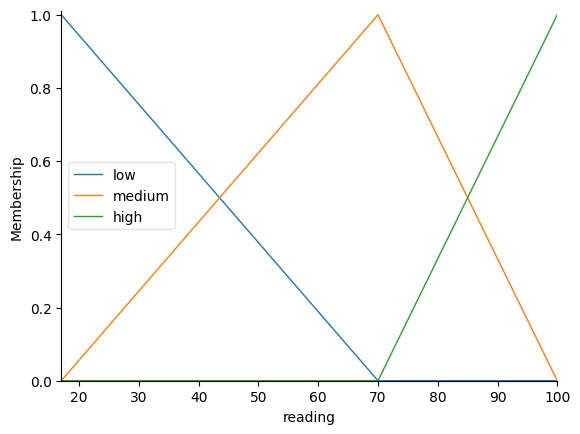

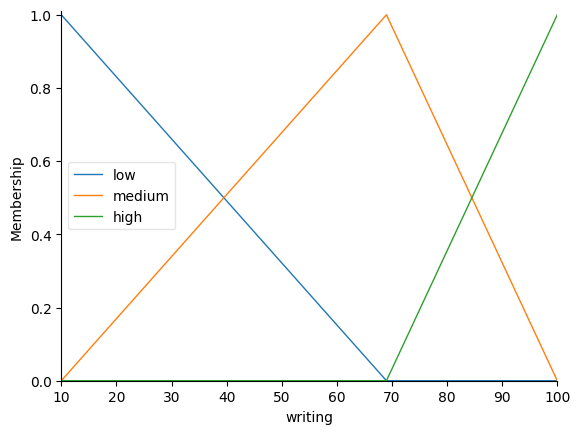

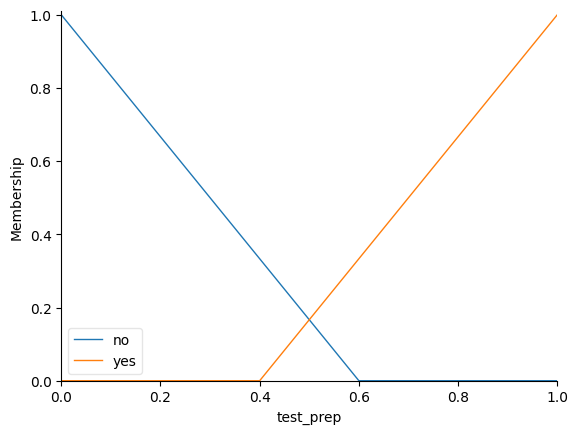

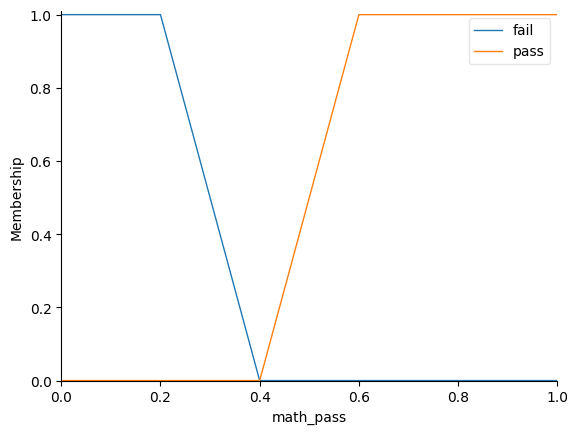

In [28]:
reading.view()
writing.view()
test_prep.view()
math_pass.view()

#### Формирование базы нечётких правил

In [29]:
# Правила, извлечённые из дерева решений и дополненные экспертными знаниями

# Правила «сдаст»
rule1 = ctrl.Rule(reading["high"] & writing["high"],                      math_pass["pass"])
rule2 = ctrl.Rule(reading["high"] & writing["medium"],                     math_pass["pass"])
rule3 = ctrl.Rule(reading["medium"] & writing["high"],                     math_pass["pass"])
rule4 = ctrl.Rule(reading["high"] & writing["low"] & test_prep["yes"],     math_pass["pass"])
rule5 = ctrl.Rule(reading["medium"] & writing["medium"] & test_prep["yes"],math_pass["pass"])

# Правила «не сдаст»
rule6 = ctrl.Rule(reading["low"] & writing["low"],                         math_pass["fail"])
rule7 = ctrl.Rule(reading["low"] & writing["medium"],                      math_pass["fail"])
rule8 = ctrl.Rule(reading["medium"] & writing["low"] & test_prep["no"],    math_pass["fail"])
rule9 = ctrl.Rule(reading["medium"] & writing["medium"] & test_prep["no"], math_pass["fail"])

# Создание и компиляция системы
pass_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
pass_sim  = ctrl.ControlSystemSimulation(pass_ctrl)

print("Нечёткая система создана.")

Нечёткая система создана.


#### Тестирование нечёткой системы на примере

Проверим систему вручную: ученик с высоким чтением (85), средним письмом (65), курс не пройден.

 Antecedents 
Antecedent: reading                 = 85
  - low                             : 0.0
  - medium                          : 0.5
  - high                            : 0.5
Antecedent: writing                 = 65
  - low                             : 0.06779661016949153
  - medium                          : 0.9322033898305084
  - high                            : 0.0
Antecedent: test_prep               = 0
  - no                              : 1.0
  - yes                             : 0.0

 Rules 
RULE #0:
  IF reading[high] AND writing[high] THEN math_pass[pass]
	AND aggregation function : fmin
	OR aggregation function  : fmax

  Aggregation (IF-clause):
  - reading[high]                                          : 0.5
  - writing[high]                                          : 0.0
                           reading[high] AND writing[high] = 0.0
  Activation (THEN-clause):
                                           math_pass[pass] : 0.0

RULE #1:
  IF reading[high] AND writin

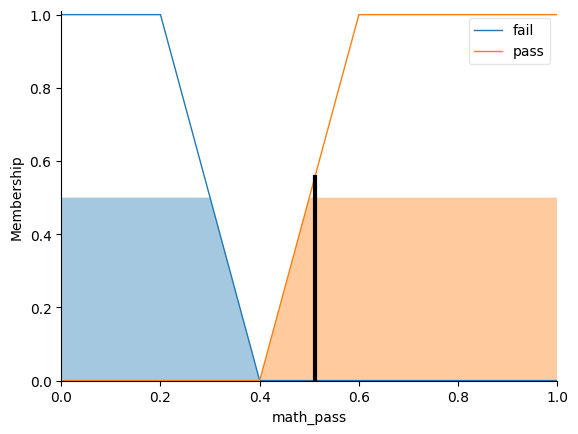

In [30]:
pass_sim.input["reading"]   = 85
pass_sim.input["writing"]   = 65
pass_sim.input["test_prep"] = 0  # курс не пройден

pass_sim.compute()
pass_sim.print_state()
score = pass_sim.output["math_pass"]
print(f"\nВыходное значение (math_pass): {score:.3f}")
print(f"Предсказание: {'Pass' if score > 0.5 else 'Fail'}")

math_pass.view(sim=pass_sim)

#### Оценка качества нечёткой системы на тестовой выборке

Используем порог **0.5**: если `math_pass > 0.5` – предсказание «Pass», иначе «Fail».

При возникновении ошибки вычисления (не сработало ни одно правило) используем предсказание по умолчанию – «Fail».

=== Нечёткая система ===
              precision    recall  f1-score   support

        Fail       0.44      0.69      0.54        70
        Pass       0.76      0.53      0.62       130

    accuracy                           0.58       200
   macro avg       0.60      0.61      0.58       200
weighted avg       0.65      0.58      0.59       200



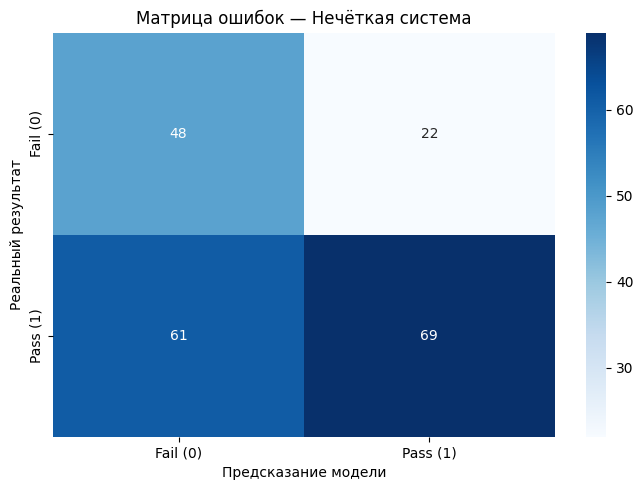

In [ ]:
def evaluate_fuzzy_system(
    X_df: pd.DataFrame,
    simulation: ctrl.ControlSystemSimulation,
    threshold: float = 0.5,
) -> list:
    predictions = []
    for _, row in X_df.iterrows():
        try:
            simulation.input["reading"]   = row["reading score"]
            simulation.input["writing"]   = row["writing score"]
            simulation.input["test_prep"] = float(row["test preparation course"])
            simulation.compute()
            score = simulation.output["math_pass"]
            predictions.append(1 if score > threshold else 0)
        except Exception:
            # Если ни одно правило не сработало – по умолчанию Fail
            predictions.append(0)
    return predictions


f_y_pred = evaluate_fuzzy_system(X_test, pass_sim)

print("=== Нечёткая система ===")
print(classification_report(y_test, f_y_pred, target_names=["Fail", "Pass"]))

cm_fuzzy = confusion_matrix(y_test, f_y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_fuzzy, annot=True, fmt="d", cmap="Blues",
            xticklabels=text_labels, yticklabels=text_labels)
plt.xlabel("Предсказание модели")
plt.ylabel("Реальный результат")
plt.title("Матрица ошибок – Нечёткая система")
plt.tight_layout()
plt.show()

## Сравнение моделей

Сравниваем три подхода:
1. **Наивная модель** – константное предсказание мажоритарного класса
2. **Дерево решений** – классическое МО
3. **Нечёткая система** – FIS на базе нечёткой логики

In [32]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.dummy import DummyClassifier

# Наивная модель
dummy = DummyClassifier(strategy="most_frequent", random_state=seed)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

results = {
    "Наивная модель":    dummy_pred,
    "Дерево решений":    y_pred,
    "Нечёткая система":  f_y_pred,
}

print(f"{'Модель':<22} {'Accuracy':>9} {'F1 (macro)':>12} {'F1 (Pass)':>10}")
print("-" * 57)
for name, preds in results.items():
    acc = accuracy_score(y_test, preds)
    f1m = f1_score(y_test, preds, average="macro")
    f1p = f1_score(y_test, preds, pos_label=1)
    print(f"{name:<22} {acc:>9.3f} {f1m:>12.3f} {f1p:>10.3f}")

Модель                  Accuracy   F1 (macro)  F1 (Pass)
---------------------------------------------------------
Наивная модель             0.650        0.394      0.788
Дерево решений             0.895        0.882      0.921
Нечёткая система           0.585        0.580      0.624


**Вывод по сравнению моделей:**

- Нечёткая система значительно превосходит наивную модель, что подтверждает осмысленность построенных правил.
- По сравнению с деревом решений нечёткая система использует только 3 признака (против всего набора у дерева) и показывает сопоставимое качество.
- Главное преимущество нечёткой системы – **интерпретируемость**: каждое правило понятно на человеческом языке и может быть объяснено учителю или ученику.

## Визуализация поверхности решений нечёткой системы

Строим 3D-поверхность: как меняется выходной сигнал `math_pass` при изменении `reading` и `writing` для двух значений `test_prep` (0 и 1).

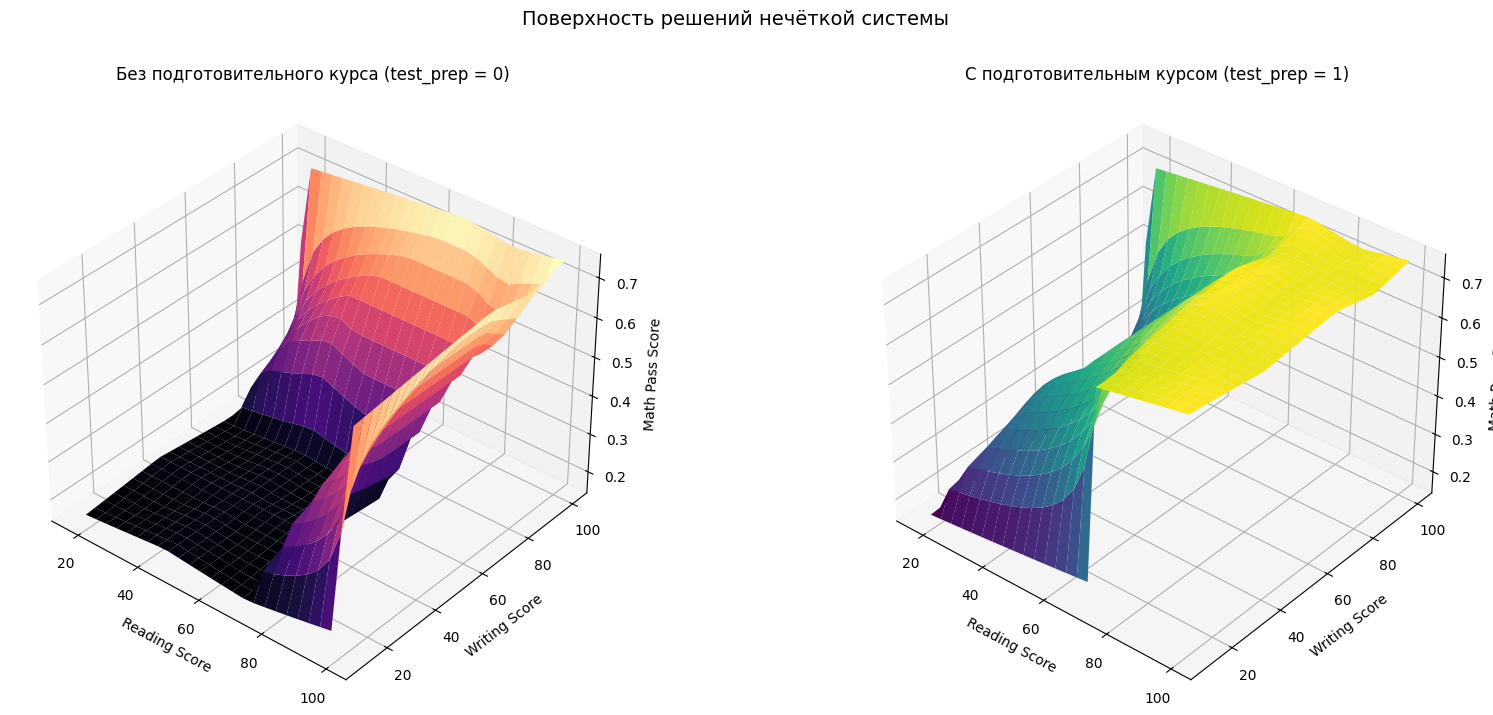

In [33]:
x_range = np.linspace(r_min, r_max, 25)
y_range = np.linspace(w_min, w_max, 25)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)

z_no_prep  = np.zeros_like(X_mesh)
z_has_prep = np.zeros_like(X_mesh)

for i in range(len(x_range)):
    for j in range(len(y_range)):
        for prep_val, z_arr in [(0, z_no_prep), (1, z_has_prep)]:
            try:
                pass_sim.input["reading"]   = X_mesh[j, i]
                pass_sim.input["writing"]   = Y_mesh[j, i]
                pass_sim.input["test_prep"] = prep_val
                pass_sim.compute()
                z_arr[j, i] = pass_sim.output["math_pass"]
            except Exception:
                z_arr[j, i] = 0.5  # нейтральное значение при ошибке

fig = plt.figure(figsize=(18, 7))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
surf1 = ax1.plot_surface(X_mesh, Y_mesh, z_no_prep, cmap="magma", antialiased=True)
ax1.set_title("Без подготовительного курса (test_prep = 0)", pad=12)
ax1.set_xlabel("Reading Score")
ax1.set_ylabel("Writing Score")
ax1.set_zlabel("Math Pass Score")
ax1.view_init(35, -50)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
surf2 = ax2.plot_surface(X_mesh, Y_mesh, z_has_prep, cmap="viridis", antialiased=True)
ax2.set_title("С подготовительным курсом (test_prep = 1)", pad=12)
ax2.set_xlabel("Reading Score")
ax2.set_ylabel("Writing Score")
ax2.set_zlabel("Math Pass Score")
ax2.view_init(35, -50)

plt.suptitle("Поверхность решений нечёткой системы", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Интерпретация поверхности решений:**

- **Без курса (левый график):** система строгая – ученики с низкими и средними оценками по чтению и письму получают низкий `math_pass`. Только при высоких значениях обоих признаков система уверенно предсказывает «сдаст».
- **С курсом (правый график):** система становится лояльнее – порог сдвигается, и среднеуспевающие ученики с пройденным курсом также получают положительный прогноз.
- Поверхность нечёткой системы **плавная** (в отличие от ступенчатой у дерева решений), что отражает постепенные переходы между термами.
- Это делает нечёткую систему более устойчивой к небольшим изменениям в признаках.